# Analisys

## Source golden tables

In [1]:
gold_source = (
    "/home/baptvit/Documents/github/graphrag-on-fhir/evaluations/data/gold/microsoft/"
)

In [2]:
import glob
import os

import pandas as pd

all_files = glob.glob(os.path.join(gold_source, "*.csv"))

df_gold = pd.concat((pd.read_csv(f) for f in all_files), ignore_index=True)

In [3]:
df_gold.columns

Index(['consumer_id', 'experiment_1', 'expriment_1_name', 'experiment_2',
       'expriment_2_name', 'experiment_1_output', 'experiment_2_output',
       'model_evaluation', 'response', 'comprehensiveness', 'diversity',
       'empowerment', 'directness', 'overall_winner'],
      dtype='object')

In [4]:
target_df = df_gold[
    [
        "consumer_id",
        "experiment_1",
        "experiment_2",
        "expriment_1_name",
        "expriment_2_name",
        "comprehensiveness",
        "diversity",
        "empowerment",
        "directness",
        "overall_winner",
    ]
]

In [5]:
target_df.count()

consumer_id          720
experiment_1         720
experiment_2         720
expriment_1_name     720
expriment_2_name     720
comprehensiveness    700
diversity            700
empowerment          700
directness           700
overall_winner       700
dtype: int64

In [6]:
target_df.tail()

,consumer_id,experiment_1,experiment_2,expriment_1_name,expriment_2_name,comprehensiveness,diversity,empowerment,directness,overall_winner
715,Milton509_Ortiz186_d66b5418-06cb-fc8a-8c13-856...,Q1:gpt-4o-2024-08-06:similarity_search_0_hop,Q1:gpt-4o-2024-08-06:lexical_search_0_hop,SimilaritySearch0HopStrategy,LexicalSearch0HopStrategy,Answer 1,Answer 1,Answer 1,Answer 2,Answer 1
716,Milton509_Ortiz186_d66b5418-06cb-fc8a-8c13-856...,Q1:gpt-4o-2024-08-06:similarity_search_0_hop,Q1:gpt-4o-2024-08-06:similarity_search_1_hop,SimilaritySearch0HopStrategy,SimilaritySearch1HopStrategy,Answer 2,Answer 2,Answer 2,Answer 2,Answer 2
717,Milton509_Ortiz186_d66b5418-06cb-fc8a-8c13-856...,Q1:gpt-4o-2024-08-06:lexical_search_1_hop,Q1:gpt-4o-2024-08-06:lexical_search_0_hop,LexicalSearch1HopStrategy,LexicalSearch0HopStrategy,Answer 1,Answer 1,Answer 1,Answer 2,Answer 1
718,Milton509_Ortiz186_d66b5418-06cb-fc8a-8c13-856...,Q1:gpt-4o-2024-08-06:lexical_search_1_hop,Q1:gpt-4o-2024-08-06:similarity_search_1_hop,LexicalSearch1HopStrategy,SimilaritySearch1HopStrategy,Answer 1,Answer 1,Answer 1,Answer 2,Answer 1
719,Milton509_Ortiz186_d66b5418-06cb-fc8a-8c13-856...,Q1:gpt-4o-2024-08-06:lexical_search_0_hop,Q1:gpt-4o-2024-08-06:similarity_search_1_hop,LexicalSearch0HopStrategy,SimilaritySearch1HopStrategy,Answer 2,Answer 2,Answer 2,Answer 1,Answer 2


In [7]:
target_df[["question", "model", "search_type"]] = target_df["experiment_1"].str.split(":", expand=True)
target_df = target_df.replace("anthropic.claude-v3-5-sonnet-v2", "anthropic.claude-v3-opus")
target_df = target_df.replace("gpt-4o-2024-11-20", "gpt-4o-2024-08-06")

/tmp/ipykernel_104607/1986405258.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  target_df[["question", "model", "search_type"]] = target_df["experiment_1"].str.split(":", expand=True)
/tmp/ipykernel_104607/1986405258.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  target_df[["question", "model", "search_type"]] = target_df["experiment_1"].str.split(":", expand=True)
/tmp/ipykernel_104607/1986405258.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try

### Count by the answer 

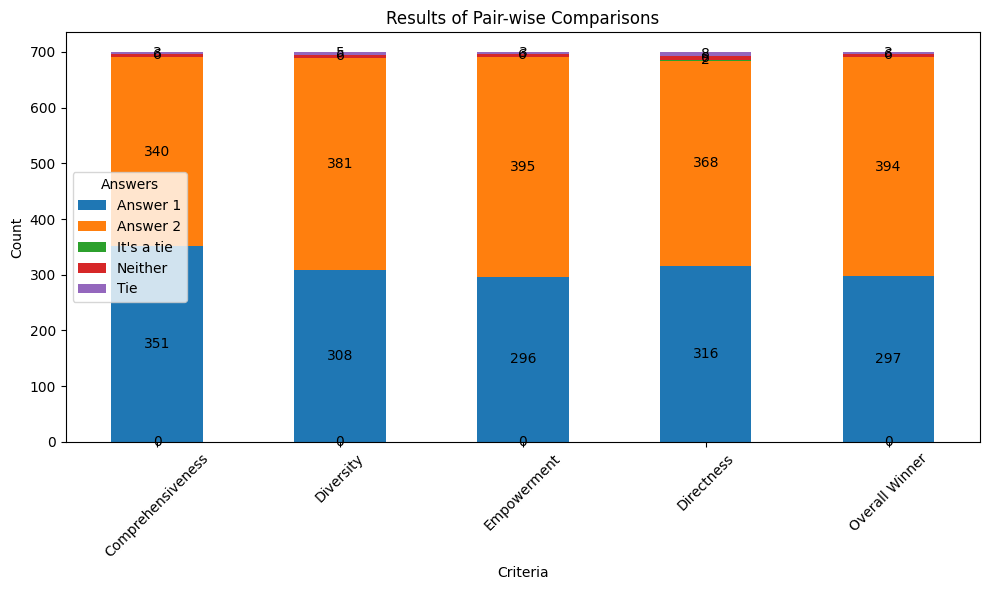

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# Count the number of times Answer 1 and Answer 2 were chosen for each criterion
counts = {
    criterion: target_df[criterion].value_counts()
    for criterion in [
        "comprehensiveness",
        "diversity",
        "empowerment",
        "directness",
        "overall_winner",
    ]
}

# Convert counts into a DataFrame for plotting
count_df = pd.DataFrame(counts).fillna(0)

# Plotting
fig, ax = plt.subplots(figsize=(10, 6))

# Create a bar plot
count_df.T.plot(kind="bar", stacked=True, ax=ax)
ax.set_title("Results of Pair-wise Comparisons")
ax.set_ylabel("Count")
ax.set_xlabel("Criteria")
ax.legend(title="Answers")
ax.set_xticklabels(
    ["Comprehensiveness", "Diversity", "Empowerment", "Directness", "Overall Winner"],
    rotation=45,
)

# Adding value on top of each bar
for i, bars in enumerate(ax.containers):
    ax.bar_label(bars, label_type="center")

plt.tight_layout()
plt.show()

### Resume analisys

In [9]:
def count_wins(df, answer):
    count_dict = {}
    for column in [
        "comprehensiveness",
        "diversity",
        "empowerment",
        "directness",
        "overall_winner",
    ]:
        count_dict[column] = (df[column] == answer).sum()
    return count_dict


# Count wins for "Answer 1" and "Answer 2"
answer1_wins = count_wins(target_df, "Answer 1")
answer2_wins = count_wins(target_df, "Answer 2")


# Overall stats
def print_analysis():
    print("Analysis of Pair-wise Comparison Results:")
    print("\nTotal comparisons:", len(target_df))
    print("\nAnswer 1 Wins by Criterion:")
    for criterion, count in answer1_wins.items():
        print(f"  {criterion.capitalize()}: {count}")

    print("\nAnswer 2 Wins by Criterion:")
    for criterion, count in answer2_wins.items():
        print(f"  {criterion.capitalize()}: {count}")

    print("\nOverall Strategy Performance:")
    overall_1_wins = target_df[target_df["overall_winner"] == "Answer 1"]
    overall_2_wins = target_df[target_df["overall_winner"] == "Answer 2"]

    strategy_performance = (
        target_df.groupby(["expriment_1_name", "expriment_2_name", "overall_winner"])
        .size()
        .unstack(fill_value=0)
    )
    print(strategy_performance)


print_analysis()

Analysis of Pair-wise Comparison Results:

Total comparisons: 720

Answer 1 Wins by Criterion:
  Comprehensiveness: 351
  Diversity: 308
  Empowerment: 296
  Directness: 316
  Overall_winner: 297

Answer 2 Wins by Criterion:
  Comprehensiveness: 340
  Diversity: 381
  Empowerment: 395
  Directness: 368
  Overall_winner: 394

Overall Strategy Performance:
overall_winner                                             Answer 1  Answer 2  \
expriment_1_name             expriment_2_name                                   
LexicalSearch0HopStrategy    SimilaritySearch1HopStrategy        49        66   
LexicalSearch1HopStrategy    LexicalSearch0HopStrategy           74        40   
                             SimilaritySearch0HopStrategy        20        18   
                             SimilaritySearch1HopStrategy        67        48   
SimilaritySearch0HopStrategy LexicalSearch0HopStrategy           42        75   
                             LexicalSearch1HopStrategy           18        6

### Comparacao head-to-head

In [10]:
# Function to calculate the head-to-head scores
def calculate_scores(df):
    # Dictionary to store the results
    results = {}

    # Iterate through the rows and accumulate the scores
    for index, row in df.iterrows():
        exp1 = row["expriment_1_name"]
        exp2 = row["expriment_2_name"]

        if (exp1, exp2) not in results:
            results[(exp1, exp2)] = {"exp1_wins": 0, "exp2_wins": 0}

        # Check who wins more criteria
        criteria = ["comprehensiveness", "diversity", "empowerment", "directness"]
        for criterion in criteria:
            if row[criterion] == "Answer 1":
                results[(exp1, exp2)]["exp1_wins"] += 1
            elif row[criterion] == "Answer 2":
                results[(exp1, exp2)]["exp2_wins"] += 1

    return results


# Calculate scores
comparison_results = calculate_scores(target_df)

# Print the results
for pair, scores in comparison_results.items():
    exp1, exp2 = pair
    print(f"Comparison between {exp1} and {exp2}:")
    print(f" - {exp1} wins: {scores['exp1_wins']} times")
    print(f" - {exp2} wins: {scores['exp2_wins']} times")
    print()

Comparison between LexicalSearch1HopStrategy and SimilaritySearch0HopStrategy:
 - LexicalSearch1HopStrategy wins: 87 times
 - SimilaritySearch0HopStrategy wins: 64 times

Comparison between LexicalSearch1HopStrategy and LexicalSearch0HopStrategy:
 - LexicalSearch1HopStrategy wins: 268 times
 - LexicalSearch0HopStrategy wins: 187 times

Comparison between LexicalSearch1HopStrategy and SimilaritySearch1HopStrategy:
 - LexicalSearch1HopStrategy wins: 266 times
 - SimilaritySearch1HopStrategy wins: 193 times

Comparison between SimilaritySearch0HopStrategy and LexicalSearch0HopStrategy:
 - SimilaritySearch0HopStrategy wins: 183 times
 - LexicalSearch0HopStrategy wins: 281 times

Comparison between SimilaritySearch0HopStrategy and SimilaritySearch1HopStrategy:
 - SimilaritySearch0HopStrategy wins: 152 times
 - SimilaritySearch1HopStrategy wins: 295 times

Comparison between LexicalSearch0HopStrategy and SimilaritySearch1HopStrategy:
 - LexicalSearch0HopStrategy wins: 210 times
 - Similarity

### Vencedor geral

In [11]:
# Function to count wins for each experiment
def calculate_win_rates(df):
    win_rates = {}

    for index, row in df.iterrows():
        exp1 = row["expriment_1_name"]
        exp2 = row["expriment_2_name"]

        if exp1 not in win_rates:
            win_rates[exp1] = 0
        if exp2 not in win_rates:
            win_rates[exp2] = 0

        # Check who won the overall category
        winner = row["overall_winner"]
        if winner == "Answer 1":
            win_rates[exp1] += 1
        elif winner == "Answer 2":
            win_rates[exp2] += 1

    return win_rates


# Calculate the win rates
win_rates = calculate_win_rates(target_df)

# Convert win rates to percentages if needed
total_matches = target_df.shape[0]
win_percentage = {k: (v / total_matches) * 100 for k, v in win_rates.items()}

# Display the results
print("Win Rates (as percentages based on overall winner):")
for experiment, percentage in win_percentage.items():
    print(f"{experiment}: {percentage:.2f}%")

Win Rates (as percentages based on overall winner):
LexicalSearch1HopStrategy: 30.97%
SimilaritySearch0HopStrategy: 14.58%
LexicalSearch0HopStrategy: 22.78%
SimilaritySearch1HopStrategy: 27.64%


### Vencedor geral - comprehensiveness

In [12]:
# Function to count wins for each experiment
def calculate_win_rates(df):
    win_rates = {}

    for index, row in df.iterrows():
        exp1 = row["expriment_1_name"]
        exp2 = row["expriment_2_name"]

        if exp1 not in win_rates:
            win_rates[exp1] = 0
        if exp2 not in win_rates:
            win_rates[exp2] = 0

        # Check who won the overall category
        winner = row["comprehensiveness"]
        if winner == "Answer 1":
            win_rates[exp1] += 1
        elif winner == "Answer 2":
            win_rates[exp2] += 1

    return win_rates


# Calculate the win rates
win_rates = calculate_win_rates(target_df)

# Convert win rates to percentages if needed
total_matches = target_df.shape[0]
win_percentage = {k: (v / total_matches) * 100 for k, v in win_rates.items()}

# Display the results
print("Win Rates (as percentages based on Comprehensiveness):")
for experiment, percentage in win_percentage.items():
    print(f"{experiment}: {percentage:.2f}%")

Win Rates (as percentages based on Comprehensiveness):
LexicalSearch1HopStrategy: 34.72%
SimilaritySearch0HopStrategy: 16.25%
LexicalSearch0HopStrategy: 20.83%
SimilaritySearch1HopStrategy: 24.17%


### Vencedor geral - diversity

In [13]:
# Function to count wins for each experiment
def calculate_win_rates(df):
    win_rates = {}

    for index, row in df.iterrows():
        exp1 = row["expriment_1_name"]
        exp2 = row["expriment_2_name"]

        if exp1 not in win_rates:
            win_rates[exp1] = 0
        if exp2 not in win_rates:
            win_rates[exp2] = 0

        # Check who won the overall category
        winner = row["diversity"]
        if winner == "Answer 1":
            win_rates[exp1] += 1
        elif winner == "Answer 2":
            win_rates[exp2] += 1

    return win_rates


# Calculate the win rates
win_rates = calculate_win_rates(target_df)

# Convert win rates to percentages if needed
total_matches = target_df.shape[0]
win_percentage = {k: (v / total_matches) * 100 for k, v in win_rates.items()}

# Display the results
print("Win Rates (as percentages based on Diversity):")
for experiment, percentage in win_percentage.items():
    print(f"{experiment}: {percentage:.2f}%")

Win Rates (as percentages based on Diversity):
LexicalSearch1HopStrategy: 30.14%
SimilaritySearch0HopStrategy: 16.25%
LexicalSearch0HopStrategy: 21.94%
SimilaritySearch1HopStrategy: 27.36%


### Vencedor geral - empowerment

In [98]:
# Function to count wins for each experiment
def calculate_win_rates(df):
    win_rates = {}

    for index, row in df.iterrows():
        exp1 = row["expriment_1_name"]
        exp2 = row["expriment_2_name"]

        if exp1 not in win_rates:
            win_rates[exp1] = 0
        if exp2 not in win_rates:
            win_rates[exp2] = 0

        # Check who won the overall category
        winner = row["empowerment"]
        if winner == "Answer 1":
            win_rates[exp1] += 1
        elif winner == "Answer 2":
            win_rates[exp2] += 1

    return win_rates


# Calculate the win rates
win_rates = calculate_win_rates(target_df)

# Convert win rates to percentages if needed
total_matches = target_df.shape[0]
win_percentage = {k: (v / total_matches) * 100 for k, v in win_rates.items()}

# Display the results
print("Win Rates (as percentages based on Empowerment):")
for experiment, percentage in win_percentage.items():
    print(f"{experiment}: {percentage:.2f}%")

Win Rates (as percentages based on Empowerment):
LexicalSearch1HopStrategy: 26.93%
SimilaritySearch0HopStrategy: 17.56%
LexicalSearch0HopStrategy: 23.21%
SimilaritySearch1HopStrategy: 28.42%


### Vencedor geral - Directness

In [99]:
# Function to count wins for each experiment
def calculate_win_rates(df):
    win_rates = {}

    for index, row in df.iterrows():
        exp1 = row["expriment_1_name"]
        exp2 = row["expriment_2_name"]

        if exp1 not in win_rates:
            win_rates[exp1] = 0
        if exp2 not in win_rates:
            win_rates[exp2] = 0

        # Check who won the overall category
        winner = row["directness"]
        if winner == "Answer 1":
            win_rates[exp1] += 1
        elif winner == "Answer 2":
            win_rates[exp2] += 1

    return win_rates


# Calculate the win rates
win_rates = calculate_win_rates(target_df)

# Convert win rates to percentages if needed
total_matches = target_df.shape[0]
win_percentage = {k: (v / total_matches) * 100 for k, v in win_rates.items()}

# Display the results
print("Win Rates (as percentages based on Directness):")
for experiment, percentage in win_percentage.items():
    print(f"{experiment}: {percentage:.2f}%")

Win Rates (as percentages based on Directness):
LexicalSearch1HopStrategy: 23.07%
SimilaritySearch0HopStrategy: 20.24%
LexicalSearch0HopStrategy: 29.02%
SimilaritySearch1HopStrategy: 22.77%


### Vencedor geral - Overall winner

In [14]:
# Function to count wins for each experiment
def calculate_win_rates(df):
    win_rates = {}

    for index, row in df.iterrows():
        exp1 = row["expriment_1_name"]
        exp2 = row["expriment_2_name"]

        if exp1 not in win_rates:
            win_rates[exp1] = 0
        if exp2 not in win_rates:
            win_rates[exp2] = 0

        # Check who won the overall category
        winner = row["overall_winner"]
        if winner == "Answer 1":
            win_rates[exp1] += 1
        elif winner == "Answer 2":
            win_rates[exp2] += 1

    return win_rates


# Calculate the win rates
win_rates = calculate_win_rates(target_df)

# Convert win rates to percentages if needed
total_matches = target_df.shape[0]
win_percentage = {k: (v / total_matches) * 100 for k, v in win_rates.items()}

# Display the results
print("Win Rates (as percentages based on Overall winner):")
for experiment, percentage in win_percentage.items():
    print(f"{experiment}: {percentage:.2f}%")

Win Rates (as percentages based on Overall winner):
LexicalSearch1HopStrategy: 30.97%
SimilaritySearch0HopStrategy: 14.58%
LexicalSearch0HopStrategy: 22.78%
SimilaritySearch1HopStrategy: 27.64%


### Matrix comparacao

In [15]:
columns_test = [
    "SimilaritySearch0HopStrategy",
    "SimilaritySearch1HopStrategy",
    "LexicalSearch0HopStrategy",
    "LexicalSearch1HopStrategy",
]

pd.DataFrame(index=columns_test, columns=columns_test, data=0)

,SimilaritySearch0HopStrategy,SimilaritySearch1HopStrategy,LexicalSearch0HopStrategy,LexicalSearch1HopStrategy
SimilaritySearch0HopStrategy,0,0,0,0
SimilaritySearch1HopStrategy,0,0,0,0
LexicalSearch0HopStrategy,0,0,0,0
LexicalSearch1HopStrategy,0,0,0,0


#### Comprehensiveness

In [16]:
# Initialize an empty dataframe to hold the comparison matrix
comparison_matrix = pd.DataFrame(index=columns_test, columns=columns_test, data=0)

# Criteria to compare
criteria = ["comprehensiveness"]

# Compute the pairwise comparison
for index, row in target_df.iterrows():
    exp1 = row["expriment_1_name"]
    exp2 = row["expriment_2_name"]

    # Calculate scores based on which answer won per criterion
    exp1_score = sum(1 for criterion in criteria if row[criterion] == "Answer 1")
    exp2_score = sum(1 for criterion in criteria if row[criterion] == "Answer 2")

    # Update matrix based on scores, adding to the current value
    comparison_matrix.at[exp1, exp2] += exp2_score
    comparison_matrix.at[exp2, exp1] += exp1_score

# Fill diagonal with NaN because comparing the same experiment yields no information
# np.fill_diagonal(comparison_matrix.values, np.nan)

comparison_matrix

,SimilaritySearch0HopStrategy,SimilaritySearch1HopStrategy,LexicalSearch0HopStrategy,LexicalSearch1HopStrategy
SimilaritySearch0HopStrategy,0,77,69,84
SimilaritySearch1HopStrategy,35,0,54,79
LexicalSearch0HopStrategy,48,61,0,87
LexicalSearch1HopStrategy,34,36,27,0


In [17]:
comparison_matrix.to_dict()

{'SimilaritySearch0HopStrategy': {'SimilaritySearch0HopStrategy': 0,
  'SimilaritySearch1HopStrategy': 35,
  'LexicalSearch0HopStrategy': 48,
  'LexicalSearch1HopStrategy': 34},
 'SimilaritySearch1HopStrategy': {'SimilaritySearch0HopStrategy': 77,
  'SimilaritySearch1HopStrategy': 0,
  'LexicalSearch0HopStrategy': 61,
  'LexicalSearch1HopStrategy': 36},
 'LexicalSearch0HopStrategy': {'SimilaritySearch0HopStrategy': 69,
  'SimilaritySearch1HopStrategy': 54,
  'LexicalSearch0HopStrategy': 0,
  'LexicalSearch1HopStrategy': 27},
 'LexicalSearch1HopStrategy': {'SimilaritySearch0HopStrategy': 84,
  'SimilaritySearch1HopStrategy': 79,
  'LexicalSearch0HopStrategy': 87,
  'LexicalSearch1HopStrategy': 0}}

#### All

In [18]:
# Initialize an empty dataframe to hold the comparison matrix
comparison_matrix = pd.DataFrame(index=columns_test, columns=columns_test, data=0)

# Criteria to compare
criteria = [
    "comprehensiveness",
    "diversity",
    "empowerment",
    "directness",
    "overall_winner",
]

# Compute the pairwise comparison
for index, row in target_df.iterrows():
    exp1 = row["expriment_1_name"]
    exp2 = row["expriment_2_name"]

    # Calculate scores based on which answer won per criterion
    exp1_score = sum([1 for criterion in criteria if row[criterion] == "Answer 1"])
    exp2_score = sum([1 for criterion in criteria if row[criterion] == "Answer 2"])

    # Update matrix based on scores, adding to the current value
    comparison_matrix.at[exp1, exp2] += exp2_score
    comparison_matrix.at[exp2, exp1] += exp1_score

# Fill diagonal with NaN because comparing the same experiment yields no information
# np.fill_diagonal(comparison_matrix.values, np.nan)

comparison_matrix

,SimilaritySearch0HopStrategy,SimilaritySearch1HopStrategy,LexicalSearch0HopStrategy,LexicalSearch1HopStrategy
SimilaritySearch0HopStrategy,0,380,356,384
SimilaritySearch1HopStrategy,179,0,259,333
LexicalSearch0HopStrategy,225,315,0,342
LexicalSearch1HopStrategy,205,241,227,0


In [19]:
comparison_matrix.to_dict()

{'SimilaritySearch0HopStrategy': {'SimilaritySearch0HopStrategy': 0,
  'SimilaritySearch1HopStrategy': 179,
  'LexicalSearch0HopStrategy': 225,
  'LexicalSearch1HopStrategy': 205},
 'SimilaritySearch1HopStrategy': {'SimilaritySearch0HopStrategy': 380,
  'SimilaritySearch1HopStrategy': 0,
  'LexicalSearch0HopStrategy': 315,
  'LexicalSearch1HopStrategy': 241},
 'LexicalSearch0HopStrategy': {'SimilaritySearch0HopStrategy': 356,
  'SimilaritySearch1HopStrategy': 259,
  'LexicalSearch0HopStrategy': 0,
  'LexicalSearch1HopStrategy': 227},
 'LexicalSearch1HopStrategy': {'SimilaritySearch0HopStrategy': 384,
  'SimilaritySearch1HopStrategy': 333,
  'LexicalSearch0HopStrategy': 342,
  'LexicalSearch1HopStrategy': 0}}

#### Resumo geral

In [20]:
# Initialize a DataFrame to hold the pairwise scores
experiments = np.unique(target_df[["expriment_1_name", "expriment_2_name"]].values)
pairwise_matrix = pd.DataFrame(0, index=experiments, columns=experiments)


# Function to update the pairwise matrix
def update_scores(row):
    criteria = [
        "comprehensiveness",
        "diversity",
        "empowerment",
        "directness",
        "overall_winner",
    ]

    for criterion in criteria:
        answer1 = "Answer 1"
        answer2 = "Answer 2"

        if row[criterion] == answer1:
            pairwise_matrix.loc[row["expriment_1_name"], row["expriment_2_name"]] += 1
        elif row[criterion] == answer2:
            pairwise_matrix.loc[row["expriment_2_name"], row["expriment_1_name"]] += 1


# Iterate over each row in the DataFrame and update scores accordingly
target_df.apply(update_scores, axis=1)

# Display the resulting pairwise comparison matrix
print("Pairwise comparison matrix:")
print(pairwise_matrix)

# Calculate rankings: count of criteria won over alternative strategies
total_wins = pairwise_matrix.sum(axis=1)
rankings = total_wins.rank(ascending=False)

print("\nTotal wins by each experiment strategy:")
print(total_wins)

print("\nRanking of each experiment strategy:")
print(rankings)

Pairwise comparison matrix:
                              LexicalSearch0HopStrategy  \
LexicalSearch0HopStrategy                             0   
LexicalSearch1HopStrategy                           342   
SimilaritySearch0HopStrategy                        225   
SimilaritySearch1HopStrategy                        315   

                              LexicalSearch1HopStrategy  \
LexicalSearch0HopStrategy                           227   
LexicalSearch1HopStrategy                             0   
SimilaritySearch0HopStrategy                        205   
SimilaritySearch1HopStrategy                        241   

                              SimilaritySearch0HopStrategy  \
LexicalSearch0HopStrategy                              356   
LexicalSearch1HopStrategy                              384   
SimilaritySearch0HopStrategy                             0   
SimilaritySearch1HopStrategy                           380   

                              SimilaritySearch1HopStrategy  
LexicalS

#### Overall analisys per question

In [21]:
target_df.columns

Index(['consumer_id', 'experiment_1', 'experiment_2', 'expriment_1_name',
       'expriment_2_name', 'comprehensiveness', 'diversity', 'empowerment',
       'directness', 'overall_winner', 'question', 'model', 'search_type'],
      dtype='object')

In [22]:
experiments_name = np.unique(target_df[["experiment_1", "experiment_2"]].values)

In [23]:
questions = ()

In [24]:
list_question = list(set([expertiment.split(":")[0] for expertiment in experiments_name]))

In [25]:
list_question.sort()

In [26]:
target_df.loc[target_df["experiment_1"].str.contains(list_question[0])]

,consumer_id,experiment_1,experiment_2,expriment_1_name,expriment_2_name,comprehensiveness,diversity,empowerment,directness,overall_winner,question,model,search_type
42,Jacklyn830_Veum823_e0e1f21a-22a7-d166-7bb1-63f...,Q1:gemini-1.5-pro:lexical_search_1_hop,Q1:gemini-1.5-pro:similarity_search_0_hop,LexicalSearch1HopStrategy,SimilaritySearch0HopStrategy,Answer 1,Answer 2,Answer 2,Answer 2,Answer 2,Q1,gemini-1.5-pro,lexical_search_1_hop
43,Jacklyn830_Veum823_e0e1f21a-22a7-d166-7bb1-63f...,Q1:gemini-1.5-pro:lexical_search_1_hop,Q1:gemini-1.5-pro:lexical_search_0_hop,LexicalSearch1HopStrategy,LexicalSearch0HopStrategy,NaN,NaN,NaN,NaN,NaN,Q1,gemini-1.5-pro,lexical_search_1_hop
44,Jacklyn830_Veum823_e0e1f21a-22a7-d166-7bb1-63f...,Q1:gemini-1.5-pro:lexical_search_1_hop,Q1:gemini-1.5-pro:similarity_search_1_hop,LexicalSearch1HopStrategy,SimilaritySearch1HopStrategy,Answer 1,Answer 1,Answer 2,Answer 2,Answer 2,Q1,gemini-1.5-pro,lexical_search_1_hop
45,Jacklyn830_Veum823_e0e1f21a-22a7-d166-7bb1-63f...,Q1:gemini-1.5-pro:similarity_search_0_hop,Q1:gemini-1.5-pro:lexical_search_0_hop,SimilaritySearch0HopStrategy,LexicalSearch0HopStrategy,Answer 1,Answer 1,Answer 1,Answer 2,Answer 1,Q1,gemini-1.5-pro,similarity_search_0_hop
46,Jacklyn830_Veum823_e0e1f21a-22a7-d166-7bb1-63f...,Q1:gemini-1.5-pro:similarity_search_0_hop,Q1:gemini-1.5-pro:similarity_search_1_hop,SimilaritySearch0HopStrategy,SimilaritySearch1HopStrategy,Answer 1,Answer 2,Answer 2,Answer 2,Answer 2,Q1,gemini-1.5-pro,similarity_search_0_hop
...,...,...,...,...,...,...,...,...,...,...,...,...,...
715,Milton509_Ortiz186_d66b5418-06cb-fc8a-8c13-856...,Q1:gpt-4o-2024-08-06:similarity_search_0_hop,Q1:gpt-4o-2024-08-06:lexical_search_0_hop,SimilaritySearch0HopStrategy,LexicalSearch0HopStrategy,Answer 1,Answer 1,Answer 1,Answer 2,Answer 1,Q1,gpt-4o-2024-08-06,similarity_search_0_hop
716,Milton509_Ortiz186_d66b5418-06cb-fc8a-8c13-856...,Q1:gpt-4o-2024-08-06:similarity_search_0_hop,Q1:gpt-4o-2024-08-06:similarity_search_1_hop,SimilaritySearch0HopStrategy,SimilaritySearch1HopStrategy,Answer 2,Answer 2,Answer 2,Answer 2,Answer 2,Q1,gpt-4o-2024-08-06,similarity_search_0_hop
717,Milton509_Ortiz186_d66b5418-06cb-fc8a-8c13-856...,Q1:gpt-4o-2024-08-06:lexical_search_1_hop,Q1:gpt-4o-2024-08-06:lexical_search_0_hop,LexicalSearch1HopStrategy,LexicalSearch0HopStrategy,Answer 1,Answer 1,Answer 1,Answer 2,Answer 1,Q1,gpt-4o-2024-08-06,lexical_search_1_hop
718,Milton509_Ortiz186_d66b5418-06cb-fc8a-8c13-856...,Q1:gpt-4o-2024-08-06:lexical_search_1_hop,Q1:gpt-4o-2024-08-06:similarity_search_1_hop,LexicalSearch1HopStrategy,SimilaritySearch1HopStrategy,Answer 1,Answer 1,Answer 1,Answer 2,Answer 1,Q1,gpt-4o-2024-08-06,lexical_search_1_hop


In [27]:
# Function to update the pairwise matrix
def analys_by_question(list_question, target_df):
    def update_scores(row):
        criteria = [
            "comprehensiveness",
            "diversity",
            "empowerment",
            "directness",
            "overall_winner",
        ]

        for criterion in criteria:
            answer1 = "Answer 1"
            answer2 = "Answer 2"

            if row[criterion] == answer1:
                pairwise_matrix.loc[row["expriment_1_name"], row["expriment_2_name"]] += 1
            elif row[criterion] == answer2:
                pairwise_matrix.loc[row["expriment_2_name"], row["expriment_1_name"]] += 1

    # Iterate over each row in the DataFrame and update scores accordingly

    for question in list_question:
        print(f"Start analysis for question: {question}")
        # Initialize a DataFrame to hold the pairwise scores
        experiments = np.unique(
            target_df[["expriment_1_name", "expriment_2_name"]].values
        )
        pairwise_matrix = pd.DataFrame(0, index=experiments, columns=experiments)

        df_question = target_df.loc[target_df["experiment_1"].str.contains(question)]

        df_question.apply(update_scores, axis=1)

        # Display the resulting pairwise comparison matrix
        print(f"Pairwise comparison matrix for question number {question}:")
        print(pairwise_matrix)

        # Calculate rankings: count of criteria won over alternative strategies
        total_wins = pairwise_matrix.sum(axis=1)
        rankings = total_wins.rank(ascending=False)

        print(f"\nTotal wins by each experiment strategy for question number {question}:")
        print(total_wins)

        print(f"\nRanking of each experiment strategy for question number {question}:")
        print(rankings)
        print(f"Finish analysis for question: {question}\n\n\n\n")


analys_by_question(list_question, target_df)

Start analysis for question: Q1
Pairwise comparison matrix for question number Q1:
                              LexicalSearch0HopStrategy  \
LexicalSearch0HopStrategy                             0   
LexicalSearch1HopStrategy                            47   
SimilaritySearch0HopStrategy                         38   
SimilaritySearch1HopStrategy                         50   

                              LexicalSearch1HopStrategy  \
LexicalSearch0HopStrategy                            18   
LexicalSearch1HopStrategy                             0   
SimilaritySearch0HopStrategy                         26   
SimilaritySearch1HopStrategy                         43   

                              SimilaritySearch0HopStrategy  \
LexicalSearch0HopStrategy                               37   
LexicalSearch1HopStrategy                               39   
SimilaritySearch0HopStrategy                             0   
SimilaritySearch1HopStrategy                            55   

              

# By model

In [28]:
list_model =  np.unique(target_df[["model"]].values)

In [29]:
list_model

array(['anthropic.claude-v3-opus', 'gemini-1.5-pro', 'gpt-4o-2024-08-06'],
      dtype=object)

In [30]:
# Function to update the pairwise matrix
def analys_by_model(list_model, target_df):
    def update_scores(row):
        criteria = [
            "comprehensiveness",
            "diversity",
            "empowerment",
            "directness",
            "overall_winner",
        ]

        for criterion in criteria:
            answer1 = "Answer 1"
            answer2 = "Answer 2"

            if row[criterion] == answer1:
                pairwise_matrix.loc[row["expriment_1_name"], row["expriment_2_name"]] += 1
            elif row[criterion] == answer2:
                pairwise_matrix.loc[row["expriment_2_name"], row["expriment_1_name"]] += 1

    # Iterate over each row in the DataFrame and update scores accordingly

    for model in list_model:
        print(f"Start analysis for model: {model}")
        # Initialize a DataFrame to hold the pairwise scores
        experiments = np.unique(
            target_df[["expriment_1_name", "expriment_2_name"]].values
        )
        pairwise_matrix = pd.DataFrame(0, index=experiments, columns=experiments)

        df_model = target_df.loc[target_df["experiment_1"].str.contains(model)]

        df_model.apply(update_scores, axis=1)

        # Display the resulting pairwise comparison matrix
        print(f"Pairwise comparison matrix for model {model}:")
        print(pairwise_matrix)

        # Calculate rankings: count of criteria won over alternative strategies
        total_wins = pairwise_matrix.sum(axis=1)
        rankings = total_wins.rank(ascending=False)

        print(f"\nTotal wins by each experiment strategy model: {model}")
        print(total_wins)

        print(f"\nRanking of each experiment strategy for model: {model}")
        print(rankings)
        print(f"Finish analysis for model: {model}\n\n\n\n")


analys_by_model(list_model, target_df)

Start analysis for model: anthropic.claude-v3-opus
Pairwise comparison matrix for model anthropic.claude-v3-opus:
                              LexicalSearch0HopStrategy  \
LexicalSearch0HopStrategy                             0   
LexicalSearch1HopStrategy                            81   
SimilaritySearch0HopStrategy                         67   
SimilaritySearch1HopStrategy                         90   

                              LexicalSearch1HopStrategy  \
LexicalSearch0HopStrategy                            74   
LexicalSearch1HopStrategy                             0   
SimilaritySearch0HopStrategy                         47   
SimilaritySearch1HopStrategy                         69   

                              SimilaritySearch0HopStrategy  \
LexicalSearch0HopStrategy                               93   
LexicalSearch1HopStrategy                              113   
SimilaritySearch0HopStrategy                             0   
SimilaritySearch1HopStrategy                  